# Clipping percentile analysis

`custom_data_to_img.py` currently rescales every spectrogram into an 8-bit PNG using a single
**global min/max** (see `spectrogram_min_max.csv`). As `analyze_dynamic_range.ipynb` and
`analyze_spectrogram_values.ipynb` show, the per-sample dynamic range is much smaller than the
global range, so most of the 256 levels are wasted on values that (almost) never occur.

This notebook builds a pixel-value histogram of the dataset (stratified by `jammer_type` so rare
jammer classes are not swamped by the 10000 "no jammer" samples) and uses it to answer two
questions:

1. **Lower tail** - how far can we clip the noise floor before it starts discarding real
   probability mass, and how much resolution do we gain?
2. **Upper tail** - how far can we clip high values, and does it matter whether a sample is
   jammed or not? Jammer signals are the feature we care about for anomaly detection, so the
   upper clip must be chosen conservatively enough to not saturate/clip them away.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
from tqdm.notebook import trange

# import own modules
_repo_name = "ofdma-spectrum-anomalies-simulation"
_module_path = os.getcwd()[: os.getcwd().find(_repo_name) + len(_repo_name)]
sys.path.append(os.path.join(os.path.abspath(_module_path), "src"))

from utils.data_utils import get_datapath

In [2]:
DATASET_NR = 0
NUM_SU = 21

# number of samples drawn from each jammer_type group to build the pixel histogram
# (stratified so that the 5 jammer types, 2000 samples each, are represented as well
# as the 10000 "no jammer" samples)
N_PER_GROUP = 500
N_BINS = 4000
SEED = 42

datapath = get_datapath(_repo_name)
datapath = os.path.join(datapath, str(DATASET_NR))

min_max = pd.read_csv(os.path.join(datapath, "spectrogram_min_max.csv"))
min_val = float(min_max["min_val"].values[0])
max_val = float(min_max["max_val"].values[0])

labels = pd.read_csv(os.path.join(datapath, "labels.csv"))

current_res = (max_val - min_val) / 255
print(f"Number of samples: {len(labels)}")
print(f"Global range: {min_val:.3f} to {max_val:.3f} dB")
print(f"Current 8-bit resolution: {current_res:.4f} dB/level")
print(labels["jammer_type"].value_counts())

Number of samples: 20000
Global range: -183.388 to 27.147 dB
Current 8-bit resolution: 0.8256 dB/level
no jammer     10000
deceptive      2000
sweep          2000
barrage        2000
pilot          2000
random_hop     2000
Name: jammer_type, dtype: int64


In [3]:
def get_filename(sample_idx, su_idx):
    return os.path.join(
        datapath, "images", f"spectrogram-{str(sample_idx).zfill(5)}-{str(su_idx).zfill(2)}.png"
    )

## Build a stratified pixel-value histogram

Rather than looking at per-image min/max (as in `analyze_spectrogram_values.ipynb`), we histogram
**every pixel value** of a stratified sample of images, separately per `jammer_type`. This lets us
compute accurate percentiles of the *actual value distribution* (not just its extremes), and
compare the "no jammer" distribution against each jammer type's distribution.

Histograms are accumulated with fixed bins over the current global range, so memory use stays
constant regardless of how many images are processed. This can take a few minutes.

In [4]:
rng = np.random.default_rng(SEED)

jammer_types = labels["jammer_type"].unique().tolist()

sampled_idxs_by_type = {}
for jt in jammer_types:
    all_idxs = labels.index[labels["jammer_type"] == jt].to_numpy()
    n = min(N_PER_GROUP, len(all_idxs))
    sampled_idxs_by_type[jt] = rng.choice(all_idxs, size=n, replace=False)

bin_edges = np.linspace(min_val, max_val, N_BINS + 1)
hist_by_type = {jt: np.zeros(N_BINS, dtype=np.int64) for jt in jammer_types}

total_images = sum(len(idxs) for idxs in sampled_idxs_by_type.values()) * NUM_SU
p_bar = trange(total_images, desc="Building histograms")
for jt, idxs in sampled_idxs_by_type.items():
    for sample_idx in idxs:
        for su_idx in range(NUM_SU):
            img = np.array(Image.open(get_filename(sample_idx, su_idx)))
            db = img.astype(np.float32) / 255.0 * (max_val - min_val) + min_val
            h, _ = np.histogram(db.ravel(), bins=bin_edges)
            hist_by_type[jt] += h
            p_bar.update(1)
p_bar.close()

Building histograms:   0%|          | 0/63000 [00:00<?, ?it/s]

In [5]:
save_results = True
if save_results:
    npz_path = os.path.join(datapath, "spectrogram_value_histograms.npz")
    np.savez(
        npz_path,
        bin_edges=bin_edges,
        **{f"hist_{jt.replace(' ', '_')}": hist_by_type[jt] for jt in jammer_types},
    )
    print(f"Saved histograms to {npz_path}")

Saved histograms to D:\GPUAccess\Anton\ofdma-spectrum-anomalies-simulation\0\spectrogram_value_histograms.npz


In [6]:
def weighted_percentile(bin_edges, counts, percentiles):
    """Percentile of a histogram given as (bin_edges, counts), via linear interpolation of the CDF."""
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    cum = np.cumsum(counts)
    total = cum[-1]
    target = np.asarray(percentiles) / 100.0 * total
    return np.interp(target, cum, bin_centers)


combined_hist = sum(hist_by_type.values())
no_jammer_hist = hist_by_type["no jammer"]
jammer_hist = combined_hist - no_jammer_hist

print(f"Total pixels in combined histogram: {combined_hist.sum():,}")

Total pixels in combined histogram: 5,821,200,000


## 1. Lower percentiles and potential gain

The low tail should mostly be noise floor: values far below any legitimate signal or jammer power,
carrying little to no information. We look at how the combined (all samples) pixel distribution
behaves at very low percentiles, and what resolution we would gain by clipping there instead of at
the true dataset minimum.

In [7]:
low_percentiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 1, 2, 5]
low_vals = weighted_percentile(bin_edges, combined_hist, low_percentiles)

low_df = pd.DataFrame({
    "percentile": low_percentiles,
    "value_dB": low_vals,
})
low_df["resolution_dB_per_level"] = (max_val - low_df["value_dB"]) / 255
low_df["gain_vs_current"] = current_res / low_df["resolution_dB_per_level"]
low_df

,percentile,value_dB,resolution_dB_per_level,gain_vs_current
0,0.00,-168.571978,0.767527,1.075703
1,0.01,-113.221194,0.550465,1.499879
2,0.05,-105.827157,0.521468,1.583280
3,0.10,-103.319807,0.511636,1.613707
4,0.25,-99.223766,0.495573,1.666012
5,0.50,-95.925415,0.482638,1.710661
6,1.00,-93.415887,0.472797,1.746269
7,2.00,-90.116737,0.459859,1.795399
8,5.00,-86.012672,0.443765,1.860514


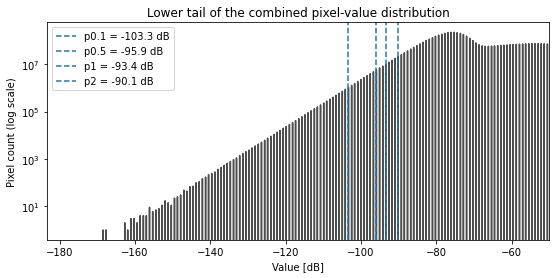

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.plot(bin_centers, combined_hist, color="0.3")
ax.set_yscale("log")
ax.set_xlim(min_val, -50)
for p, v in zip([0.1, 0.5, 1, 2], weighted_percentile(bin_edges, combined_hist, [0.1, 0.5, 1, 2])):
    ax.axvline(v, linestyle="--", label=f"p{p} = {v:.1f} dB")
ax.set_xlabel("Value [dB]")
ax.set_ylabel("Pixel count (log scale)")
ax.set_title("Lower tail of the combined pixel-value distribution")
ax.legend()
plt.show()

**Reading the table/plot:** the distribution has a long, thin low-value tail - the 0.01st
percentile already sits ~70 dB above the dataset minimum, and clipping there alone would nearly
double the effective resolution (see `gain_vs_current` for p=0.01). Percentiles between 0.1 and 1
recover most of the achievable gain from the low end (~1.6-1.75x) while discarding at most 1% of
(mostly uninformative, near-noise-floor) pixel mass. Going more aggressive than p=1 gives
diminishing returns on this side.

## 2. Higher percentiles: jammed vs. non-jammed

For the upper tail we must be careful: this is where jammer signal power lives, i.e. exactly the
feature an anomaly detector needs. We compare the "no jammer" pixel distribution against the
"jammer" (any type) distribution, and then break the jammer distribution down further by jammer
type, since jammer types differ substantially in transmit power/characteristics.

In [9]:
high_percentiles = [90, 95, 99, 99.5, 99.9, 99.95, 99.99, 100]

high_df = pd.DataFrame({
    "percentile": high_percentiles,
    "no_jammer_dB": weighted_percentile(bin_edges, no_jammer_hist, high_percentiles),
    "jammer_any_dB": weighted_percentile(bin_edges, jammer_hist, high_percentiles),
})
high_df

,percentile,no_jammer_dB,jammer_any_dB
0,90.00,-48.005462,-44.722333
1,95.00,-43.047159,-39.769384
2,99.00,-33.973512,-30.707903
3,99.50,-30.721077,-27.377533
4,99.90,-24.081025,-19.141801
5,99.95,-21.587847,-15.827450
6,99.99,-15.035407,-9.215006
7,100.00,27.120976,27.120976


In [10]:
jammer_type_order = [jt for jt in jammer_types if jt != "no jammer"]
per_type_df = pd.DataFrame({"percentile": high_percentiles})
for jt in jammer_type_order:
    per_type_df[jt] = weighted_percentile(bin_edges, hist_by_type[jt], high_percentiles)
per_type_df

,percentile,deceptive,sweep,barrage,pilot,random_hop
0,90.00,-46.377180,-47.989831,-39.733160,-48.003283,-48.015148
1,95.00,-40.617876,-42.237189,-34.817387,-43.043498,-43.051720
2,99.00,-30.719092,-33.174576,-26.537227,-33.962563,-33.962826
3,99.50,-27.361637,-29.831499,-23.226116,-30.705185,-30.700104
4,99.90,-18.286047,-20.734139,-15.826750,-24.048414,-23.239485
5,99.95,-15.016291,-16.661054,-13.330033,-20.741838,-19.974761
6,99.99,-7.537952,-9.212351,-6.765880,-13.305945,-11.715893
7,100.00,27.120976,27.120976,27.120976,27.120976,27.120976


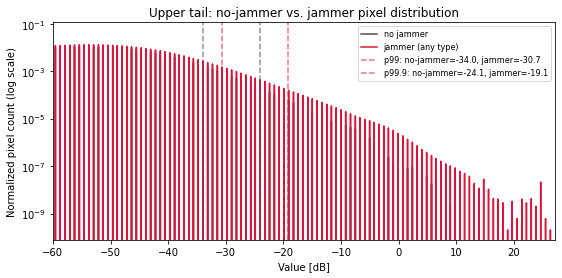

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bin_centers, no_jammer_hist / no_jammer_hist.sum(), label="no jammer", color="0.3")
ax.plot(bin_centers, jammer_hist / jammer_hist.sum(), label="jammer (any type)", color="crimson")
ax.set_yscale("log")
ax.set_xlim(-60, max_val)
for p in [99, 99.9]:
    v_nj = weighted_percentile(bin_edges, no_jammer_hist, [p])[0]
    v_j = weighted_percentile(bin_edges, jammer_hist, [p])[0]
    ax.axvline(v_nj, color="0.3", linestyle="--", alpha=0.6)
    ax.axvline(v_j, color="crimson", linestyle="--", alpha=0.6, label=f"p{p}: no-jammer={v_nj:.1f}, jammer={v_j:.1f}")
ax.set_xlabel("Value [dB]")
ax.set_ylabel("Normalized pixel count (log scale)")
ax.set_title("Upper tail: no-jammer vs. jammer pixel distribution")
ax.legend(fontsize=8)
plt.show()

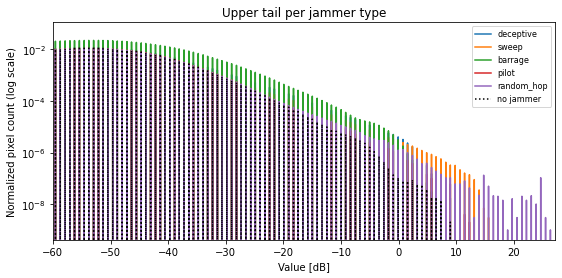

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
palette = sns.color_palette("tab10", n_colors=len(jammer_type_order))
for jt, color in zip(jammer_type_order, palette):
    h = hist_by_type[jt]
    ax.plot(bin_centers, h / h.sum(), label=jt, color=color)
ax.plot(bin_centers, no_jammer_hist / no_jammer_hist.sum(), label="no jammer", color="black", linestyle=":")
ax.set_yscale("log")
ax.set_xlim(-60, max_val)
ax.set_xlabel("Value [dB]")
ax.set_ylabel("Normalized pixel count (log scale)")
ax.set_title("Upper tail per jammer type")
ax.legend(fontsize=8)
plt.show()

**Reading the table/plots:** jammer pixels do reach higher values than no-jammer pixels at every
percentile, confirming the upper tail carries anomaly-relevant information. `barrage` is
consistently the most powerful jammer type (its p90 already matches other types' p99.9), so it
drives the conservative bound. Even so, the 99.9th percentile of the *combined jammer* distribution
still sits well below the dataset maximum (~-19 dB vs. +27 dB) - the true maximum is an extreme
outlier reached by only a handful of pixels in the whole dataset, so clipping at p99.9-p99.99 of
the jammer distribution discards a negligible, extreme fraction of jammer signal while recovering
substantial resolution.

## 3. Candidate clipping scenarios

Combining a conservative low clip (p0.1-p1 of the combined distribution) with a conservative high
clip (p99.9-p99.99 of the **jammer** distribution specifically, not the combined one, so we don't
let the 10000 "no jammer" samples pull the bound down) gives the following resolution gains.

In [13]:
candidates = [
    (0.1, 99.9),
    (0.5, 99.9),
    (1, 99.9),
    (0.1, 99.99),
    (1, 99.99),
]

rows = []
for lp, hp in candidates:
    lo = weighted_percentile(bin_edges, combined_hist, [lp])[0]
    hi = weighted_percentile(bin_edges, jammer_hist, [hp])[0]
    res = (hi - lo) / 255
    rows.append({
        "low_percentile": lp,
        "low_dB": lo,
        "high_percentile_of_jammer_dist": hp,
        "high_dB": hi,
        "resolution_dB_per_level": res,
        "gain_vs_current": current_res / res,
    })

candidates_df = pd.DataFrame(rows)
candidates_df

,low_percentile,low_dB,high_percentile_of_jammer_dist,high_dB,resolution_dB_per_level,gain_vs_current
0,0.1,-103.319807,99.90,-19.141801,0.330110,2.501078
1,0.5,-95.925415,99.90,-19.141801,0.301112,2.741936
2,1.0,-93.415887,99.90,-19.141801,0.291271,2.834578
3,0.1,-103.319807,99.99,-9.215006,0.369038,2.237247
4,1.0,-93.415887,99.99,-9.215006,0.330200,2.500398


## Conclusion

- **Low clip:** p0.5-p1 of the combined pixel distribution (~-96 to -93 dB) recovers most of the
  available low-end gain (~1.7-1.75x) without touching signal-bearing pixels - the discarded mass
  is far below any legitimate transmitter or jammer power.
- **High clip:** should be derived from the **jammer** pixel distribution, not the full/combined
  one, and conservatively (p99.9-p99.99), because jammer power - especially `barrage` - is exactly
  the signal an anomaly detector needs to see. Using the combined or no-jammer distribution alone
  would clip real jammer signal too aggressively.
- Together, **low=p1, high=p99.9 of the jammer distribution** gives ~2.8x better resolution
  (0.29 vs. 0.83 dB/level) while keeping both the near-noise-floor discard and the jammer-signal
  discard below 0.1-1%.
- Before finalizing, it would be worth checking classification/reconstruction impact empirically
  (e.g. does an anomaly detector's performance change when trained on clipped vs. unclipped
  images) rather than relying on percentiles alone.